## Setup

In [34]:
# change into the src directory
import git
import os

repo = git.Repo('.', search_parent_directories=True)
os.chdir(repo.working_tree_dir)

In [35]:
from tapas_gmm.policy.models.tpgmm import ModelType, TPGMM, ReconstructionStrategy, FittingStage, InitStrategy, _xdx_to_tangent, TPGMMConfig, AutoTPGMMConfig, AutoTPGMM, FrameSelectionConfig, DemoSegmentationConfig, CascadeConfig
# import lovely_tensors as lt
# lt.monkey_patch()
from lovely_numpy import lo
import matplotlib.pyplot as plt

import pathlib
#from pbdlib.utils.jupyter_utils import *
import numpy as np

from conf._machine import data_naming_config as machine_data_naming_config
from tapas_gmm.dataset.demos import Demos, PartialFrameViewDemos
import tapas_gmm.policy.models.tpgmm
from tapas_gmm.utils.misc import load_scene_data, DataNamingConfig
from tapas_gmm.utils.logging import setup_logger  # noqa: F401
from tapas_gmm.viz.gmm import plot_log_map_quaternions, plot_hmm_transition_matrix

%matplotlib inline

%load_ext autoreload
%autoreload 2

data_root = pathlib.Path(machine_data_naming_config.data_root).resolve()
data_root = data_root.parent / data_root.stem

np.set_printoptions(precision=2)

plt.style.use('default')

from IPython.display import HTML
from matplotlib import rc
rc('animation', html='jshtml')


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [36]:
#task = 'TurnOnLight'
serie = 'demos'
task = 'OpenDoorBack'
path = data_root / task / serie

data_config = DataNamingConfig(
    feedback_type=None,
    task=None,
    data_root=None,
    path=path,
)

scene_data = load_scene_data(data_config)
print(scene_data.sample_data_point_with_ground_truth(cam="wrist"))


SingleCamSceneObservation(
    action=Tensor(shape=torch.Size([7]), device=cpu, dtype=torch.float32, is_shared=False),
    depth=Tensor(shape=torch.Size([256, 256]), device=cpu, dtype=torch.float32, is_shared=False),
    ee_pose=Tensor(shape=torch.Size([7]), device=cpu, dtype=torch.float32, is_shared=False),
    extr=Tensor(shape=torch.Size([4, 4]), device=cpu, dtype=torch.float32, is_shared=False),
    feedback=Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.float32, is_shared=False),
    intr=Tensor(shape=torch.Size([3, 3]), device=cpu, dtype=torch.float32, is_shared=False),
    mask=Tensor(shape=torch.Size([256, 256]), device=cpu, dtype=torch.uint8, is_shared=False),
    object_poses=TensorDict(
        fields={
            base__button: Tensor(shape=torch.Size([7]), device=cpu, dtype=torch.float32, is_shared=False),
            base__drawer: Tensor(shape=torch.Size([7]), device=cpu, dtype=torch.float32, is_shared=False),
            base__slide: Tensor(shape=torch.Size([7]), 

In [37]:
gt_pose_config = {
    #'indeces': [1,2,3,4],
}

gt_kp_config = {
    'encoder_name': 'demos_keypoints_gt_encoder-world',
    'cam': 'front',
}

kp_config = {
    'encoder_name': 'demos_vit_keypoints_encoder',
    'encoding_name': 'gtcopy',
}


In [38]:
observations = scene_data.get_demos(**gt_pose_config)
print(observations[0].keys())
print(observations[0])
n_obs = len(observations)

demo_meta_data = {
    'path': path
}

data_kwargs = dict(
    meta_data=demo_meta_data,
    add_init_ee_pose_as_frame=True,
    add_world_frame=False,
    frames_from_keypoints=False,
    kp_indeces=None,
    enforce_z_up=False,
    modulo_object_z_rotation=False,
    make_quats_continuous=True
)

demos = Demos(observations, **data_kwargs)
print(demos)

_LazyStackedTensorDictKeysView(['action', 'cameras', 'ee_pose', 'feedback', 'gripper_state', 'joint_pos', 'joint_vel', 'object_poses', 'object_states'],
    include_nested=False,
    leaves_only=False)
SceneObservation(
    action=Tensor(shape=torch.Size([97, 7]), device=cpu, dtype=torch.float32, is_shared=False),
    cameras=LazyStackedTensorDict(
        fields={
            _order: CameraOrder(
                order=('wrist',),
                batch_size=torch.Size([97]),
                device=None,
                is_shared=False),
            wrist: SingleCamObservation(
                depth=Tensor(shape=torch.Size([97, 256, 256]), device=cpu, dtype=torch.float32, is_shared=False),
                extr=Tensor(shape=torch.Size([97, 4, 4]), device=cpu, dtype=torch.float32, is_shared=False),
                intr=Tensor(shape=torch.Size([97, 3, 3]), device=cpu, dtype=torch.float32, is_shared=False),
                rgb=Tensor(shape=torch.Size([97, 3, 256, 256]), device=cpu, dtype=to

In [39]:
tag="release"

tpgmm_config = TPGMMConfig(
    n_components=10,
    model_type=ModelType.HMM,
    use_riemann=True,
    add_time_component=True,
    add_action_component=False,
    position_only=False,  # Use rotation aswell?
    add_gripper_action=True,
    heal_time_variance=False,
    reg_shrink=1e-2, # 1e-2 is 0.01
    reg_diag=2e-4,
    reg_diag_gripper=2e-2,
    reg_em_finish_shrink=1e-2,
    reg_em_finish_diag=2e-4,
    reg_em_finish_diag_gripper=2e-2,

    em_steps=50,
)

frame_selection_config = FrameSelectionConfig(
    init_strategy=InitStrategy.TIME_BASED,
    fitting_actions=(FittingStage.INIT,),
    rel_score_threshold=0.75,
    use_bic=False,  # Does prune segmentation
    drop_redundant_frames=True,
    gt_frames=[
        [0, 3],
        [0, 3],
        [0, 3],
    ],
)

demos_segmentation_config = DemoSegmentationConfig(
    gripper_based=False,
    distance_based=False,
    velocity_based=True,
    velocity_threshold=0.001,
    components_prop_to_len=True,
    min_end_distance=0,
)

cascade_config = CascadeConfig()

auto_tpgmm_config = AutoTPGMMConfig(
    tpgmm=tpgmm_config,
    frame_selection=frame_selection_config,
    demos_segmentation=demos_segmentation_config,
    cascade=cascade_config,
)

In [40]:
atpgmm = AutoTPGMM(auto_tpgmm_config)


2025-08-16 03:08:07.925 | INFO     |  Fitting AutoTPGMM
2025-08-16 03:08:07.925 | INFO     |  Segmenting trajectories


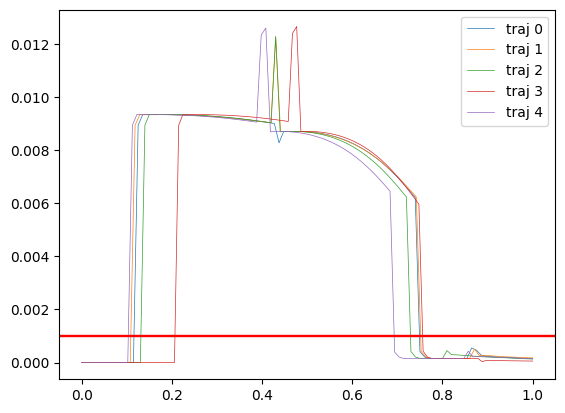

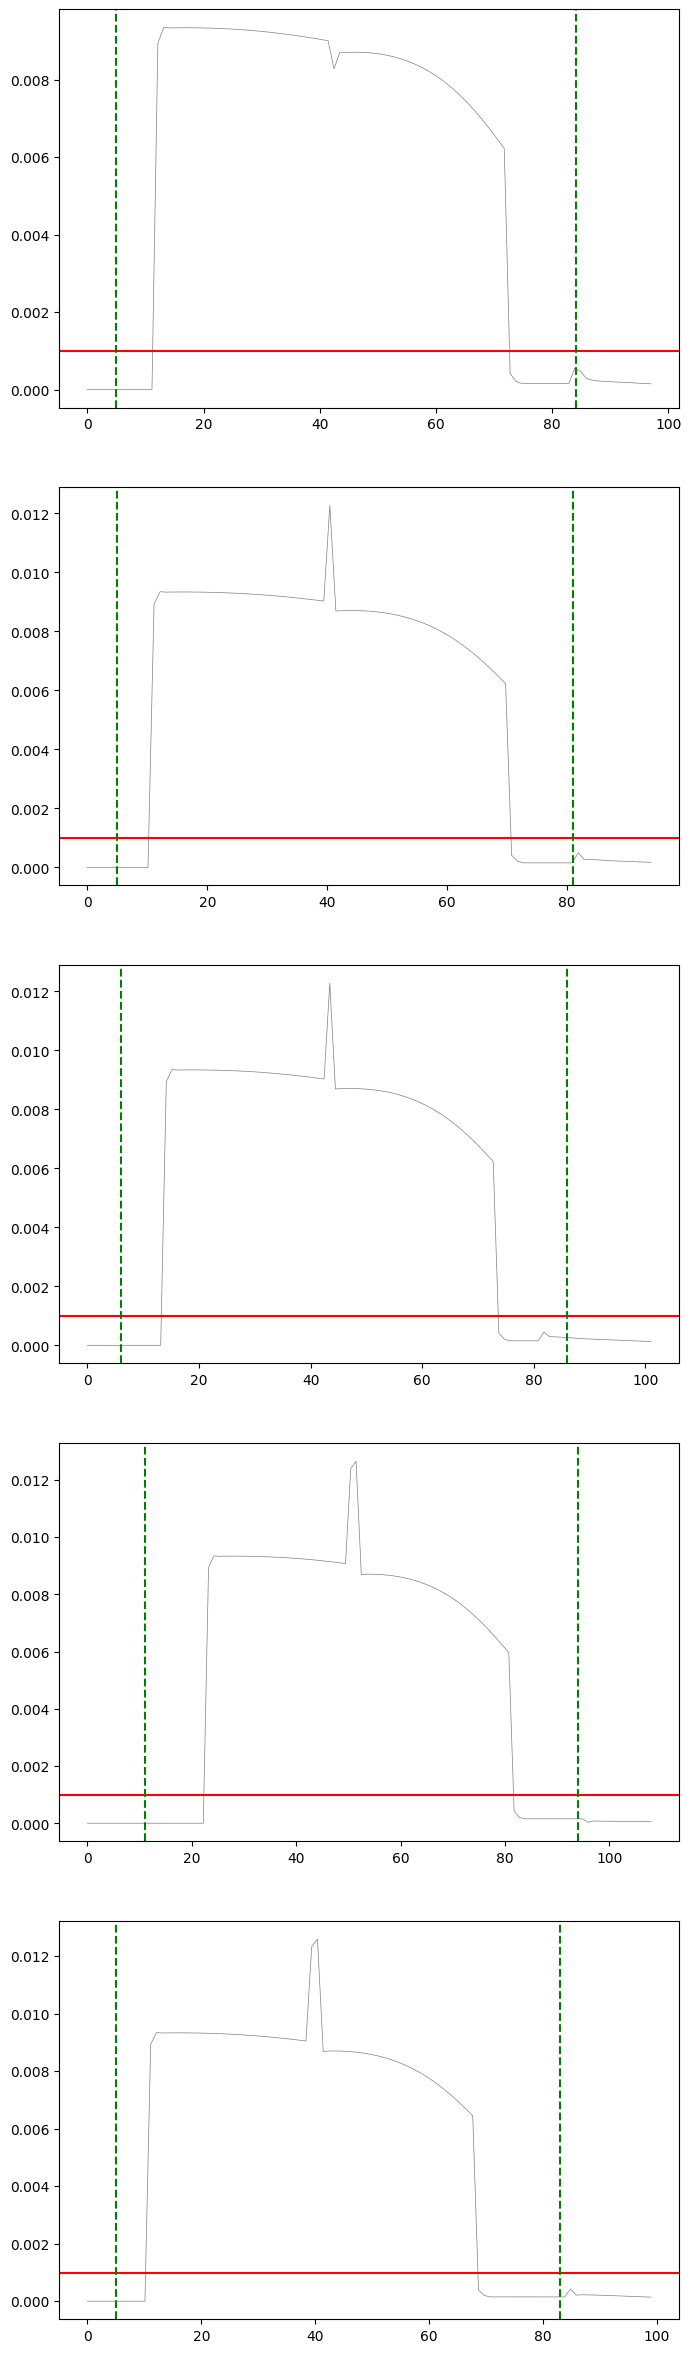

2025-08-16 03:08:08.145 | INFO     |  Creating segement of demos.
2025-08-16 03:08:08.147 | INFO     |  Subsampling to length 15 using strategy mean-length.
2025-08-16 03:08:08.147 | INFO     |  Creating segement of demos.
2025-08-16 03:08:08.149 | INFO     |  Subsampling to length 88 using strategy mean-length.
2025-08-16 03:08:08.149 | INFO     |  Creating segement of demos.
2025-08-16 03:08:08.150 | INFO     |  Subsampling to length 23 using strategy mean-length.
2025-08-16 03:08:08.151 | INFO     |  ... created 3 segments
2025-08-16 03:08:08.151 | INFO     |    Fitting candidate frame 1/10
2025-08-16 03:08:08.151 | INFO     |    Creating partial frame view of demos.
2025-08-16 03:08:08.152 | INFO     |    Changing number of components to 1


Time-based init:   0%|          | 0/1 [00:00<?, ?it/s]

2025-08-16 03:08:08.166 | INFO     |    Fitting candidate frame 2/10
2025-08-16 03:08:08.166 | INFO     |    Creating partial frame view of demos.


Time-based init:   0%|          | 0/1 [00:00<?, ?it/s]

2025-08-16 03:08:08.187 | INFO     |    Fitting candidate frame 3/10
2025-08-16 03:08:08.188 | INFO     |    Creating partial frame view of demos.


...

Fitting segments:   0%|          | 0/3 [00:00<?, ?it/s]

Time-based init:   0%|          | 0/3 [00:00<?, ?it/s]

Time-based init:   0%|          | 0/6 [00:00<?, ?it/s]

Time-based init:   0%|          | 0/3 [00:00<?, ?it/s]

((array([[1.04e+24, 1.04e+24, 8.21e+23, 5.12e+23, 2.52e+23, 9.78e+22,
          3.00e+22, 7.27e+21, 1.39e+21, 2.10e+20, 2.50e+19, 2.35e+18,
          1.75e+17, 1.03e+16, 4.75e+14, 1.04e+24, 1.04e+24, 8.21e+23,
          5.12e+23, 2.52e+23, 9.78e+22, 3.00e+22, 7.27e+21, 1.39e+21,
          2.10e+20, 2.50e+19, 2.35e+18, 1.75e+17, 1.03e+16, 4.75e+14,
          1.04e+24, 1.04e+24, 8.21e+23, 5.12e+23, 2.52e+23, 9.78e+22,
          3.00e+22, 7.27e+21, 1.39e+21, 2.10e+20, 2.50e+19, 2.35e+18,
          1.75e+17, 1.03e+16, 4.75e+14, 1.04e+24, 1.04e+24, 8.21e+23,
          5.12e+23, 2.52e+23, 9.78e+22, 3.00e+22, 7.27e+21, 1.39e+21,
          2.10e+20, 2.50e+19, 2.35e+18, 1.75e+17, 1.03e+16, 4.75e+14,
          1.04e+24, 1.04e+24, 8.21e+23, 5.12e+23, 2.52e+23, 9.78e+22,
          3.00e+22, 7.27e+21, 1.39e+21, 2.10e+20, 2.50e+19, 2.35e+18,
          1.75e+17, 1.03e+16, 4.75e+14],
         [5.12e+23, 8.21e+23, 1.04e+24, 1.04e+24, 8.21e+23, 5.12e+23,
          2.52e+23, 9.78e+22, 3.00e+22, 7.27e+21,

In [41]:
atpgmm.fit_trajectories(demos, fix_frames=True,
                       fitting_actions=(FittingStage.INIT,))


2025-08-16 03:08:10.630 | INFO     |  Did not specify time_based, deciding automatically.


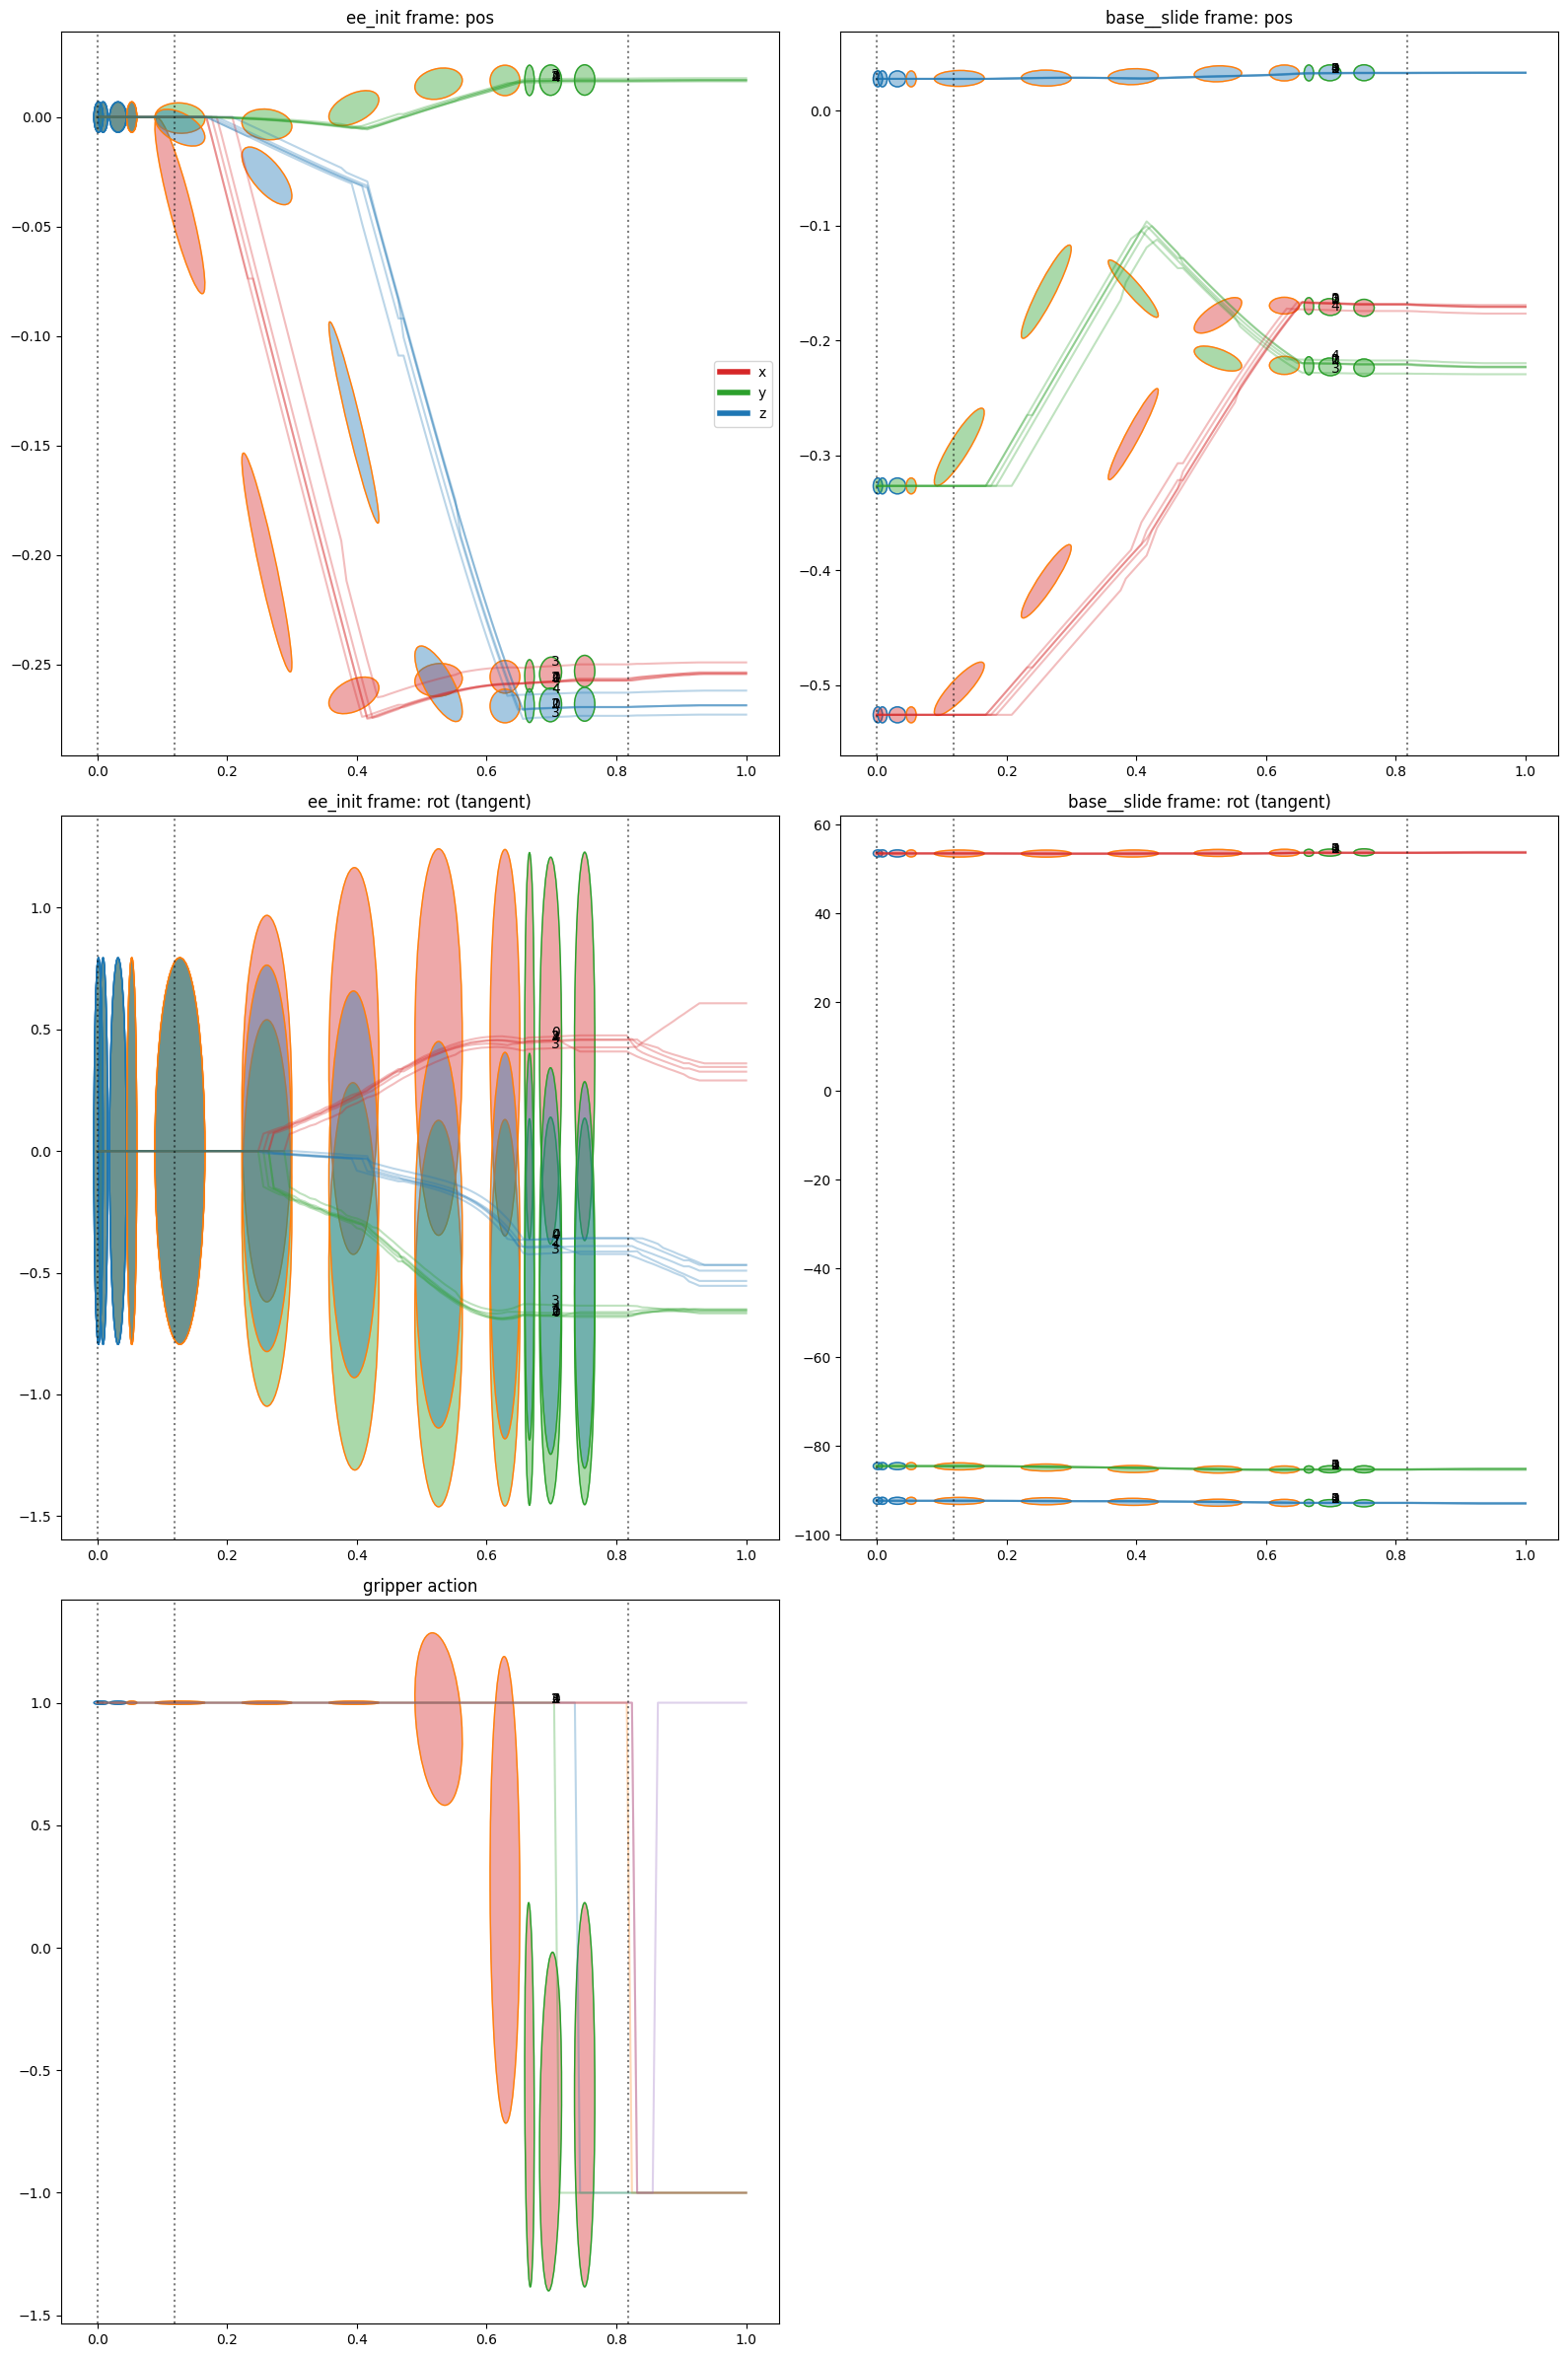

In [42]:
atpgmm.plot_model(
    scatter=True, rotations_raw=True, plot_traj=True, plot_gaussians=True,
    annotate_gaussians=False, annotate_trajs=True,
    mean_as_base=False, per_segment=False, gaussian_mean_only=False, plot_traj_means=False) #, size=(150, 10))


In [43]:
atpgmm.fit_trajectories(demos, fix_frames=True,
                       fitting_actions=(FittingStage.EM_HMM, ))


2025-08-16 03:08:11.427 | INFO     |  Fitting AutoTPGMM


Fitting segments:   0%|          | 0/3 [00:00<?, ?it/s]

HMM EM:   0%|          | 0/50 [00:00<?, ?it/s]

HMM EM:   0%|          | 0/50 [00:00<?, ?it/s]

HMM EM:   0%|          | 0/50 [00:00<?, ?it/s]

((array([[1.34e-07, 1.29e-07, 1.06e-07, 5.62e-08, 1.34e-08, 1.04e-09,
          2.04e-11, 8.33e-14, 5.92e-17, 6.21e-21, 8.15e-26, 1.13e-31,
          1.42e-38, 1.36e-46, 2.05e-49, 1.34e-07, 1.29e-07, 1.06e-07,
          5.62e-08, 1.34e-08, 1.04e-09, 2.04e-11, 8.33e-14, 5.92e-17,
          6.21e-21, 8.15e-26, 1.13e-31, 1.42e-38, 1.36e-46, 2.05e-49,
          1.34e-07, 1.29e-07, 1.06e-07, 5.62e-08, 1.34e-08, 1.04e-09,
          2.04e-11, 8.33e-14, 5.92e-17, 6.21e-21, 8.15e-26, 1.13e-31,
          1.42e-38, 1.36e-46, 2.05e-49, 1.34e-07, 1.29e-07, 1.06e-07,
          5.62e-08, 1.34e-08, 1.04e-09, 2.04e-11, 8.33e-14, 5.92e-17,
          6.21e-21, 8.15e-26, 1.13e-31, 1.42e-38, 1.36e-46, 2.05e-49,
          1.34e-07, 1.29e-07, 1.06e-07, 5.62e-08, 1.34e-08, 1.04e-09,
          2.04e-11, 8.33e-14, 5.92e-17, 6.21e-21, 8.15e-26, 1.13e-31,
          1.42e-38, 1.36e-46, 2.05e-49],
         [3.47e-23, 4.95e-09, 2.30e-08, 4.98e-08, 4.28e-08, 1.24e-08,
          1.02e-09, 2.04e-11, 8.32e-14, 5.92e-17,

2025-08-16 03:08:23.366 | INFO     |  Did not specify time_based, deciding automatically.


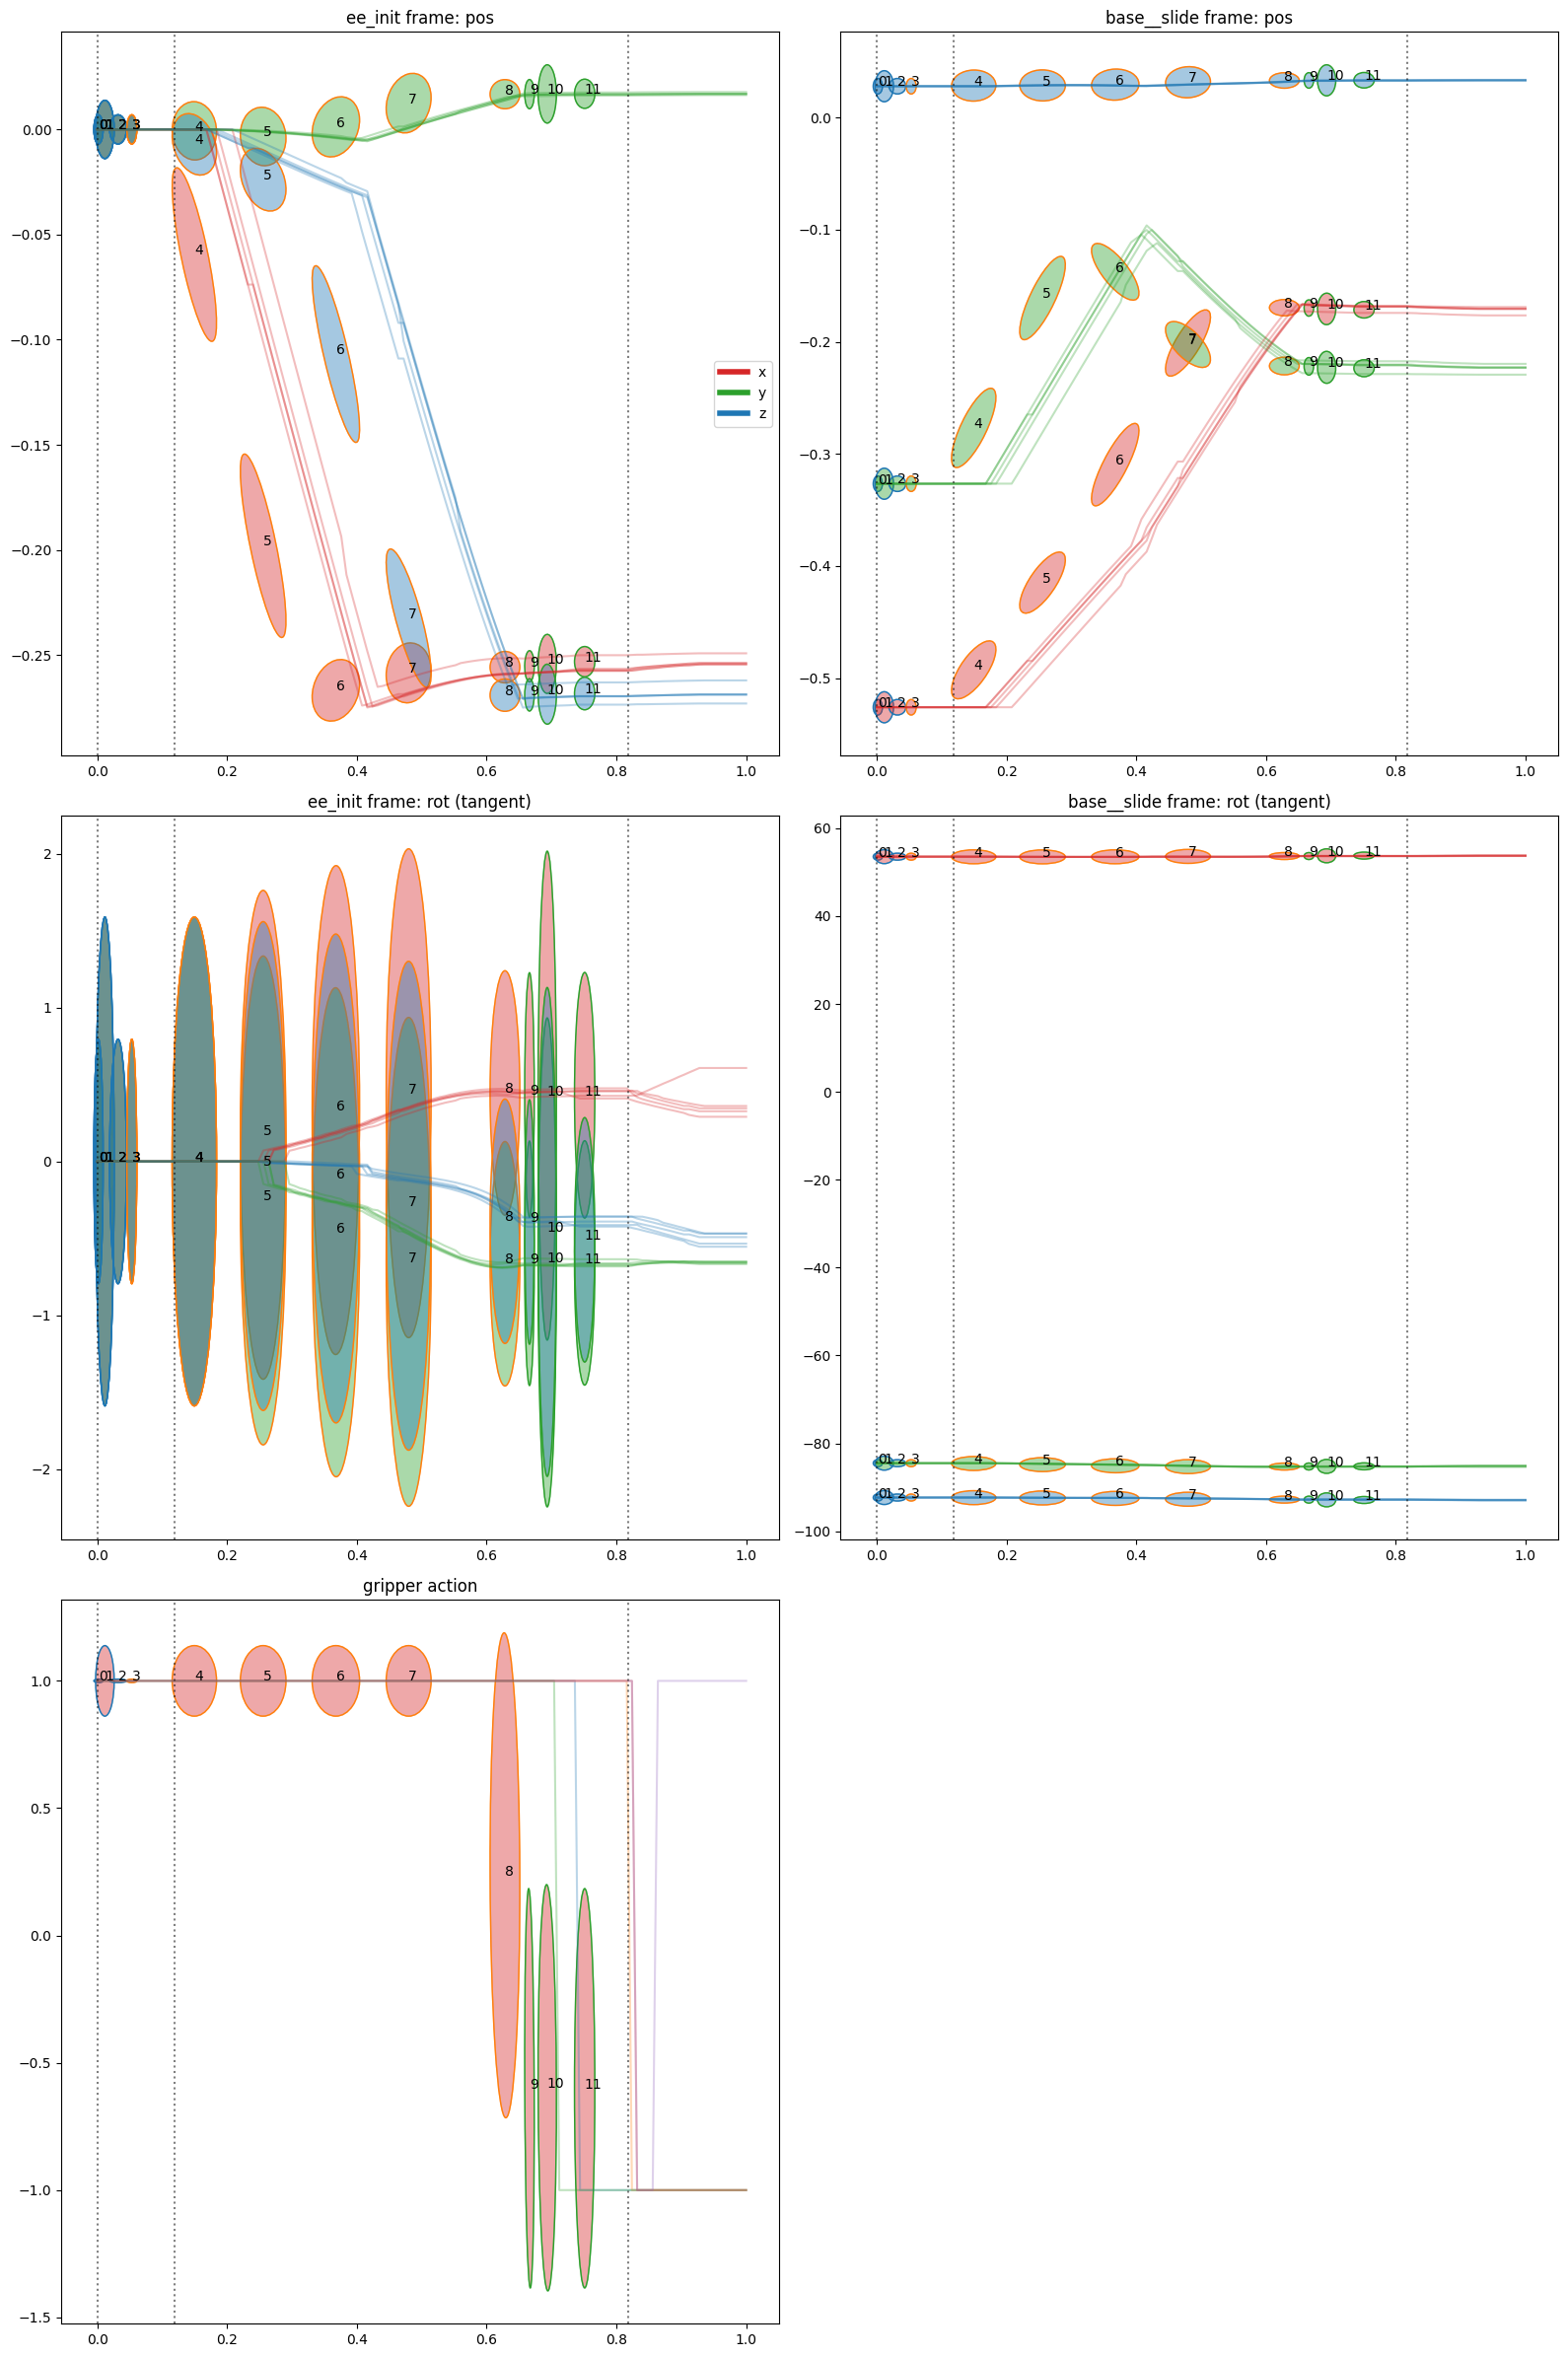

In [44]:

atpgmm.plot_model(
    scatter=True, rotations_raw=True, plot_traj=True, plot_gaussians=True,
    annotate_gaussians=True, annotate_trajs=False,
    mean_as_base=False, per_segment=False, gaussian_mean_only=False, plot_traj_means=False)

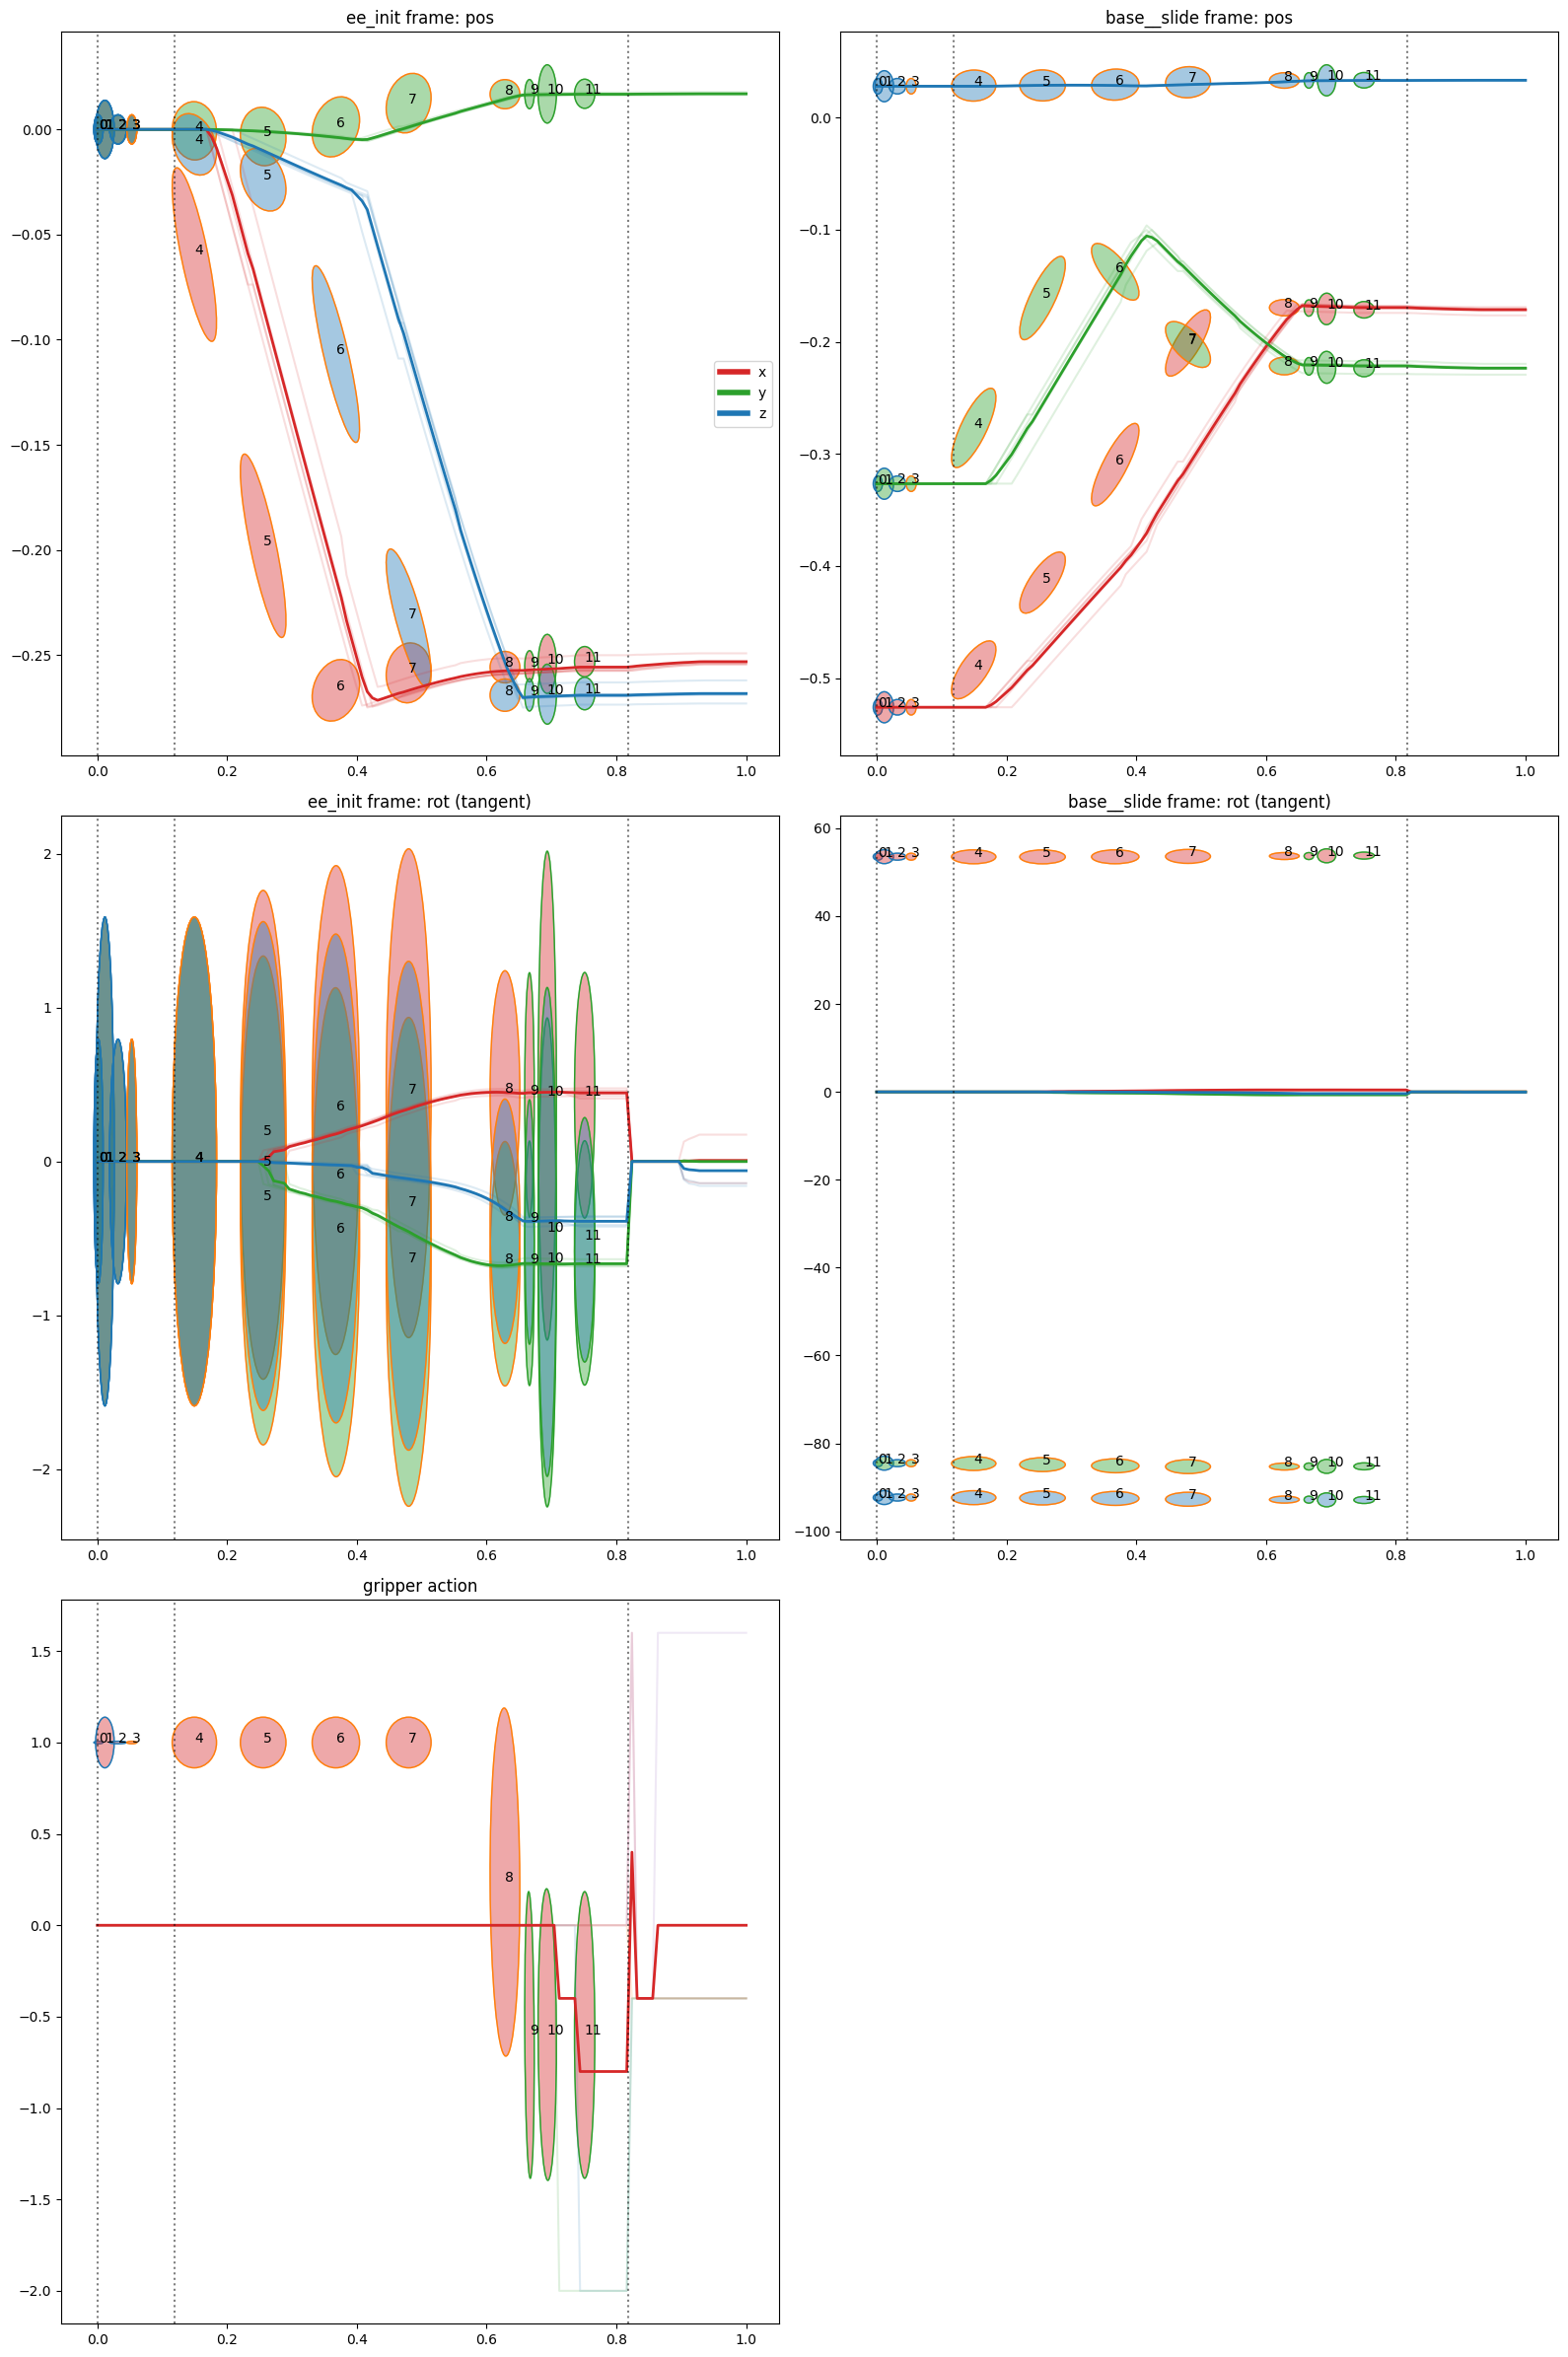

In [45]:
atpgmm.plot_model(
    scatter=True, rotations_raw=True, plot_traj=True, plot_gaussians=True,
    annotate_gaussians=True, annotate_trajs=False,
    mean_as_base=True, per_segment=False, gaussian_mean_only=False, plot_traj_means=True, time_based=True)

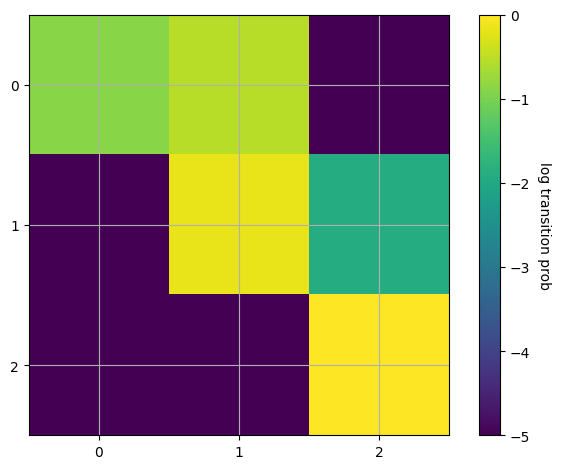

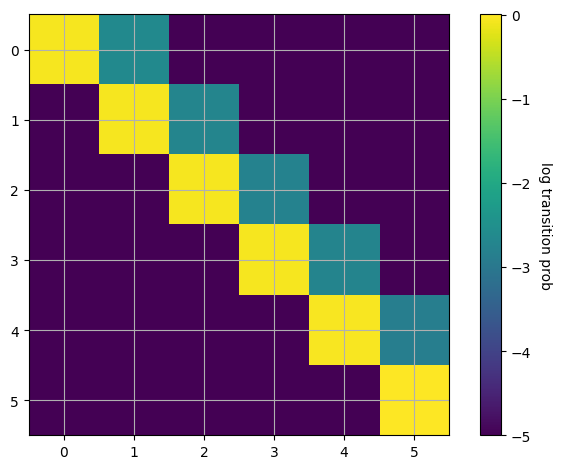

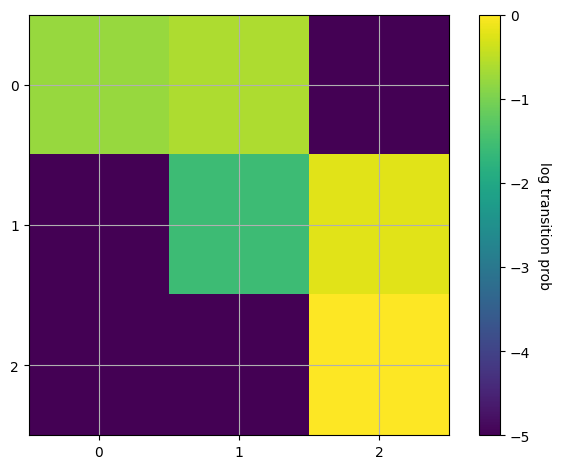

In [46]:
atpgmm.plot_hmm_transition_matrix()

In [47]:
atpgmm.to_disk(data_root / task / f'{serie}_gmm_policy-{tag}.pt')

In [48]:
seg_local_marginals, seg_trans_marginals, seg_trans_marg_container, seg_joint_models, cascaded_hmms, (reconstructions, original_trajectories, extras) = atpgmm.reconstruct(
    strategy=tapas_gmm.policy.models.tpgmm.ReconstructionStrategy.GMR,
    use_ss=False)


2025-08-16 03:08:42.925 | INFO     |  Caculated segment transition probabilities: (array([[0.02]]), array([[1.16e-07]]))
2025-08-16 03:08:42.925 | INFO     |  Creating partial frame view of demos.


Transforming marginals:   0%|          | 0/5 [00:00<?, ?it/s]

Joining marginals:   0%|          | 0/5 [00:00<?, ?it/s]

2025-08-16 03:08:42.975 | INFO     |  Creating partial frame view of demos.


Transforming marginals:   0%|          | 0/5 [00:00<?, ?it/s]

Joining marginals:   0%|          | 0/5 [00:00<?, ?it/s]

2025-08-16 03:08:43.008 | INFO     |  Creating partial frame view of demos.


Transforming marginals:   0%|          | 0/5 [00:00<?, ?it/s]

Joining marginals:   0%|          | 0/5 [00:00<?, ?it/s]

GMR:   0%|          | 0/5 [00:00<?, ?it/s]

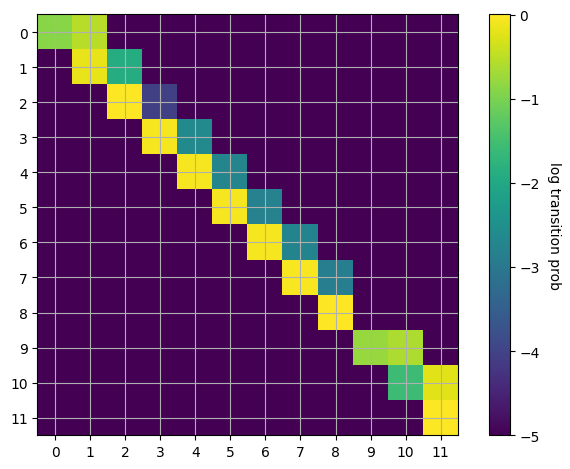

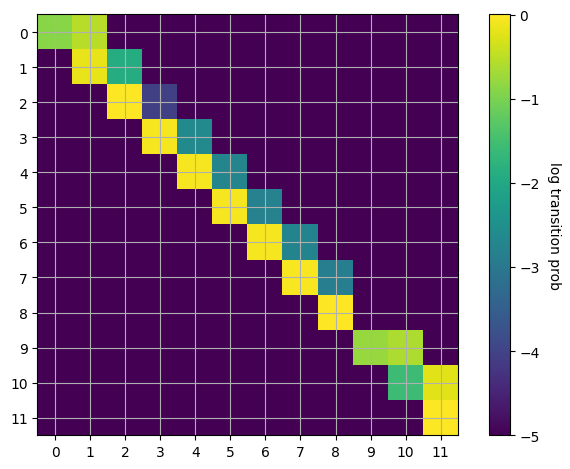

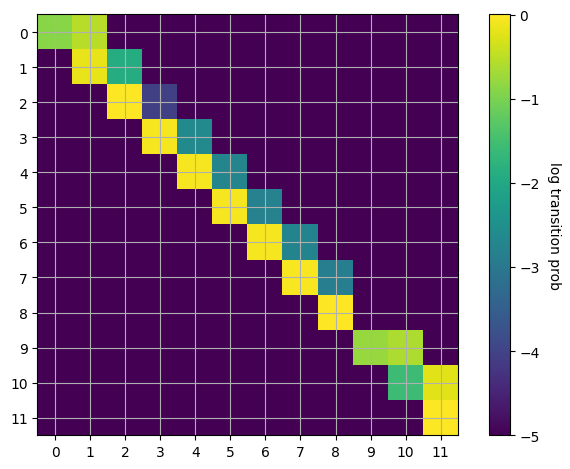

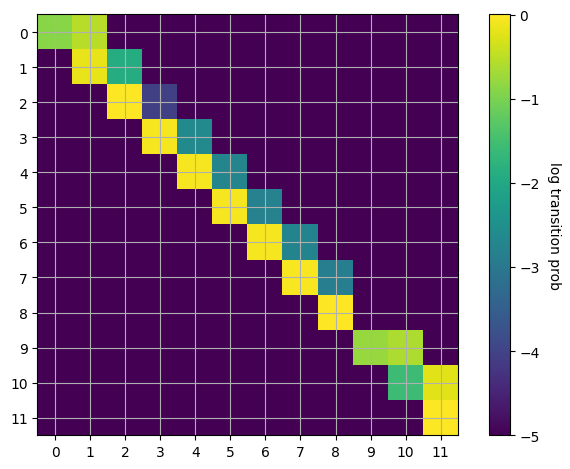

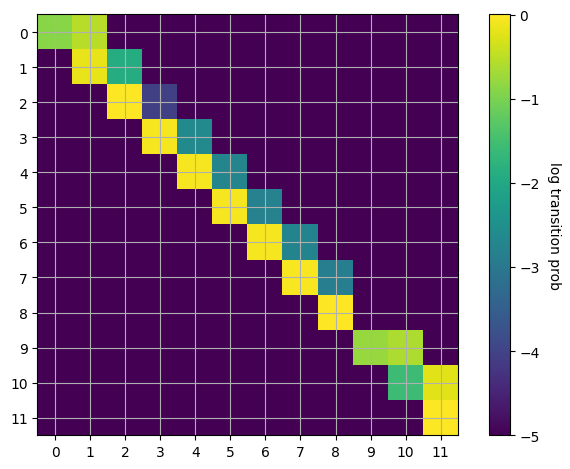

In [49]:
for cascaded_hmm in cascaded_hmms:
    plot_hmm_transition_matrix(cascaded_hmm)

2025-08-16 03:08:44.682 | INFO     |  Taking frame origins from demos.


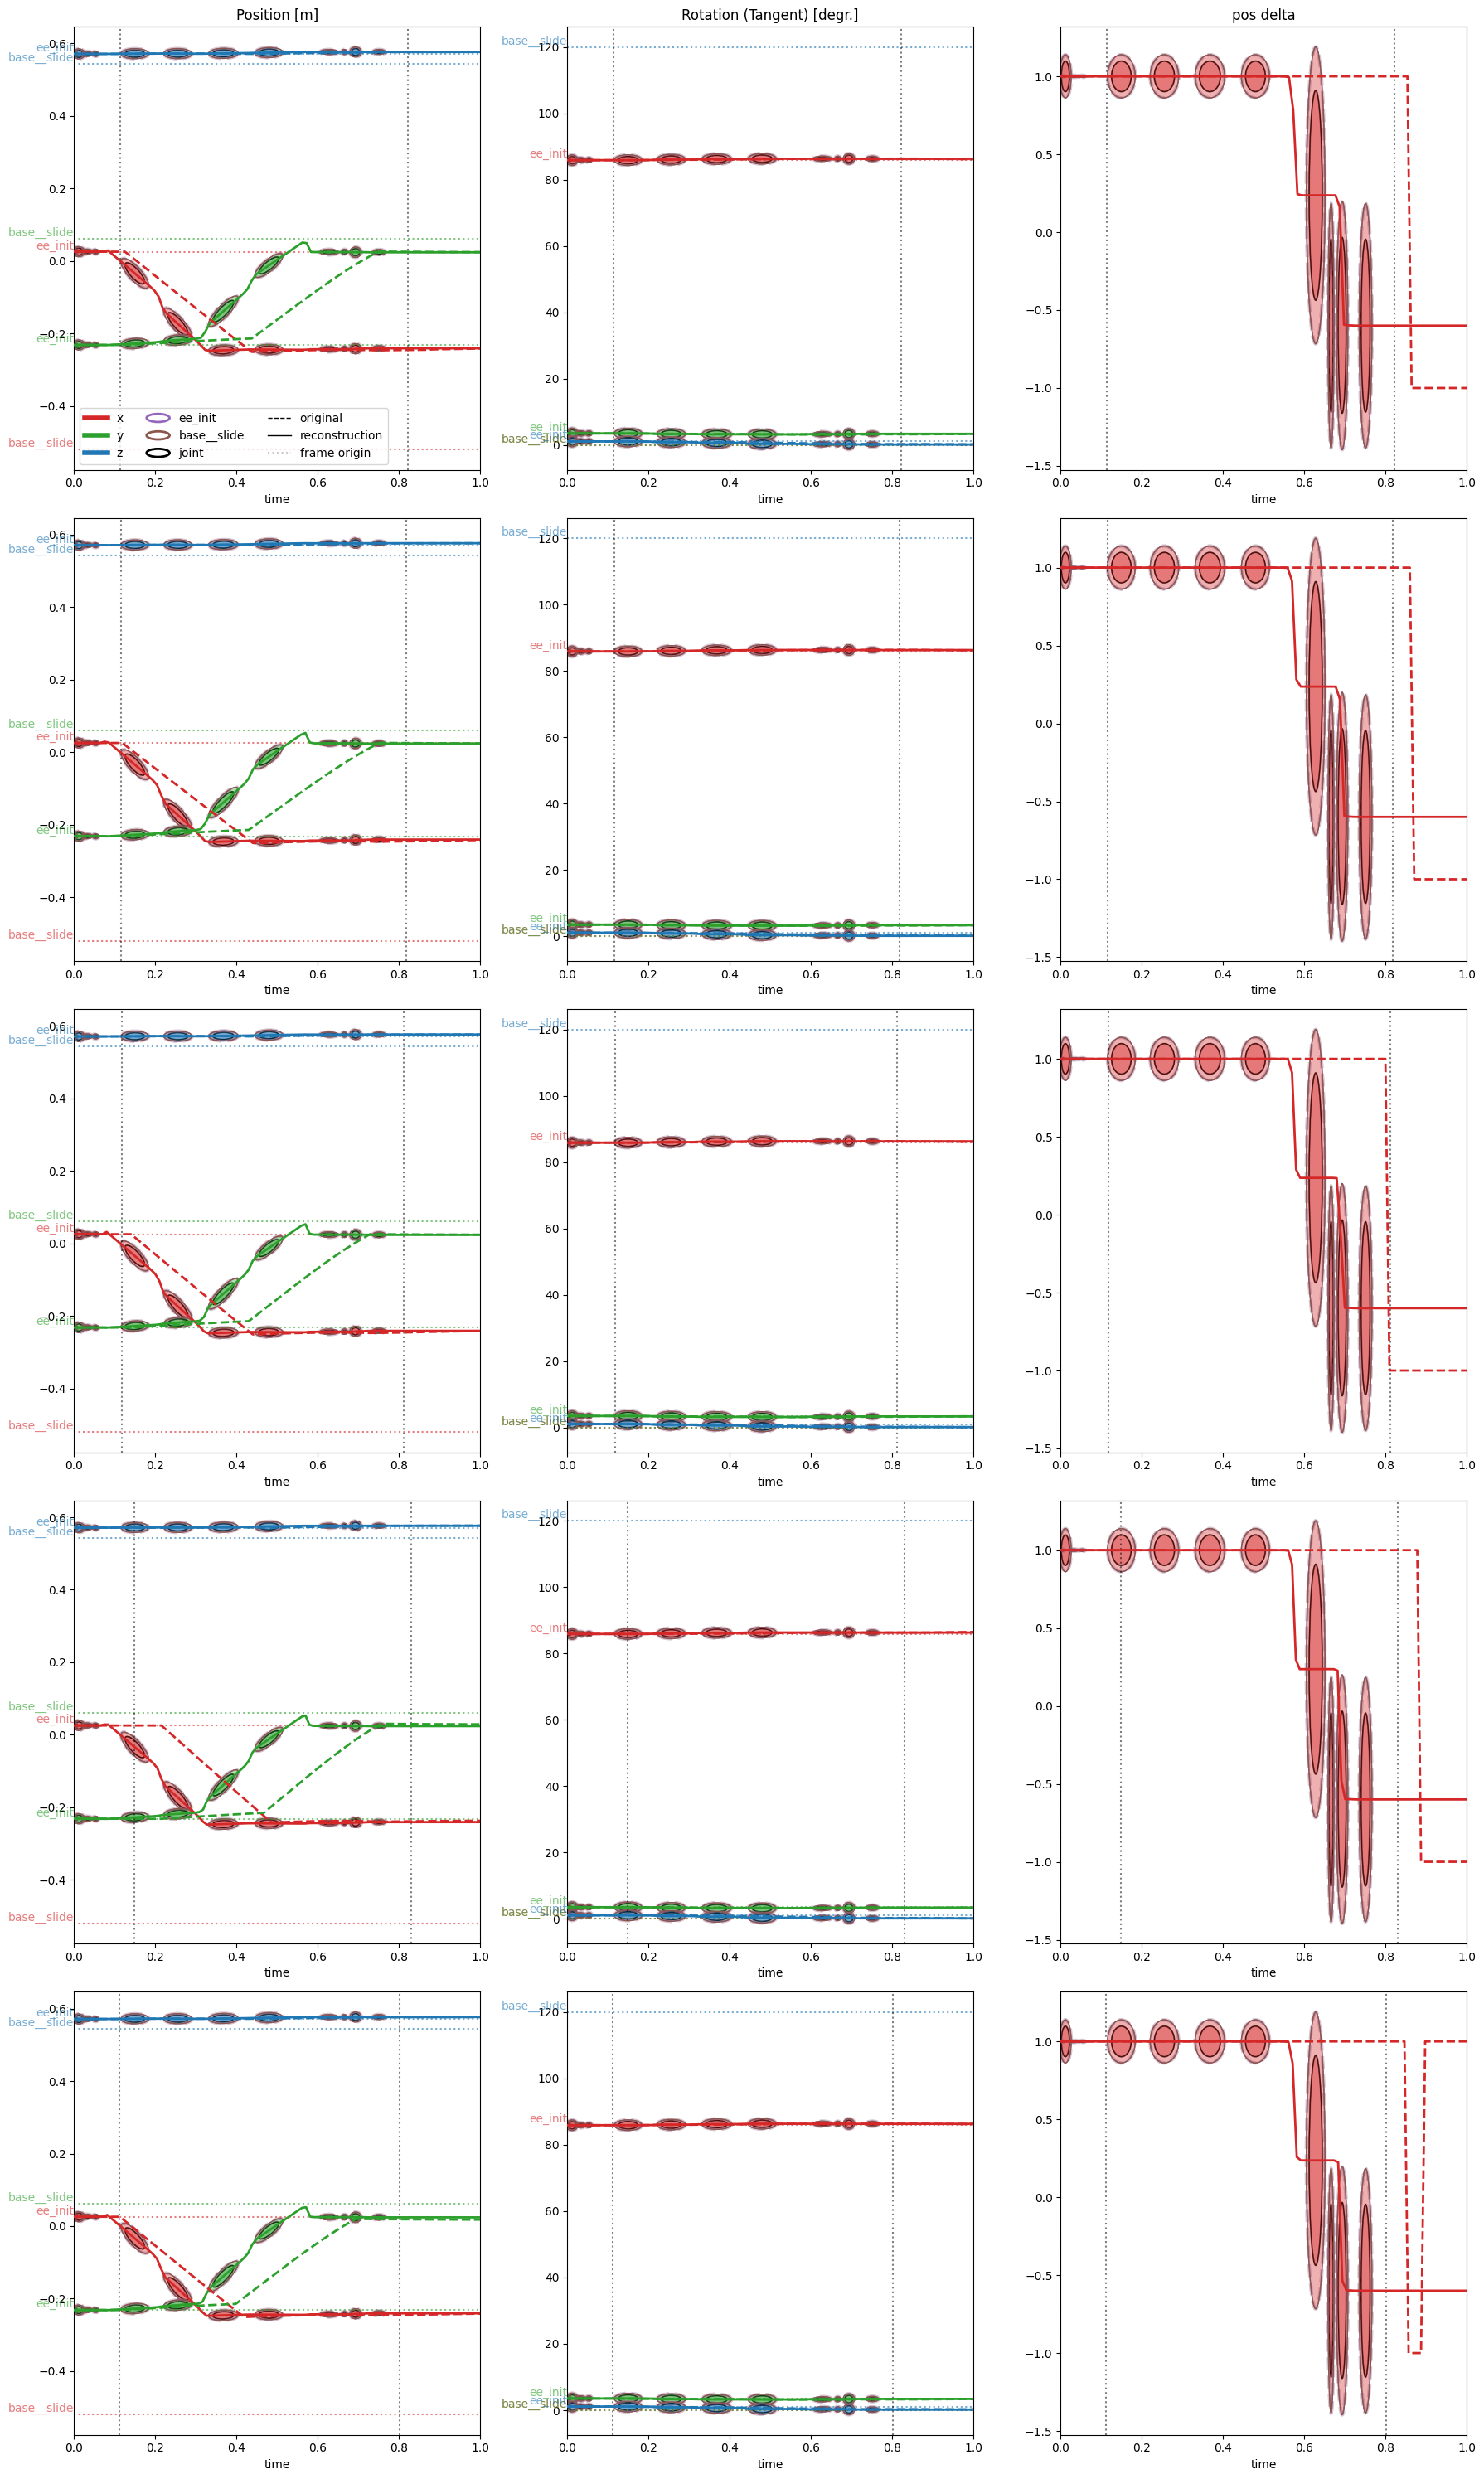

In [50]:
atpgmm.plot_reconstructions(
    seg_trans_marg_container,
    cascaded_hmms,
    reconstructions,
    original_trajectories,
    plot_trajectories=True,
    plot_reconstructions=True,
    plot_gaussians=True,
    time_based=True,
    equal_aspect=False,
    per_segment=False,
)

In [51]:
atpgmm.plot_reconstructions(
    seg_trans_marginals,
    seg_joint_models,
    reconstructions,
    original_trajectories,
    plot_trajectories=True,
    plot_reconstructions=True,
    plot_gaussians=True,
    time_based=True,
    equal_aspect=True,
    per_segment=False,
)

IndexError: tuple index out of range